In [2]:
import os
import numpy as np
import pandas as pd

## 1: 

- Import data into dataframe
- Begin EDA to understand dataset

In [3]:
urbandata = pd.read_csv("urbandata.csv")

In [4]:
urbandata.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [5]:
#Looking at descriptive stats, starting to look for outliers

urbandata.describe()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress,failure
count,456.000000,456.000000,455.000000,454.000000,452.000000,456.000000,455.000000,456.000000,453.000000,456.000000
mean,5.730263,32.592037,12.089241,3.110861,68.532487,9.271769,4.962680,2.654610,0.037108,0.368421
std,2.921622,4.738187,0.591701,1.365354,14.490899,0.790136,0.080109,0.268216,0.051781,0.482906
min,1.000000,24.924765,11.506094,0.000000,41.087602,7.426926,4.743956,2.200000,0.000000,0.000000
25%,3.000000,30.496861,11.672524,2.140594,58.594494,8.744313,4.911817,2.451540,0.010000,0.000000
50%,6.000000,31.902116,11.863909,2.925396,64.789151,9.125281,4.960576,2.595360,0.020000,0.000000
75%,8.000000,34.026756,12.332858,4.314350,76.739522,9.771380,5.010956,2.845200,0.040000,1.000000
max,11.000000,91.157913,14.823489,6.089045,125.949552,11.719278,5.249006,3.364000,0.480000,1.000000


In [6]:
#Checking for null values, looking at datatypes

urbandata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           456 non-null    int64  
 1   material_flexibility   456 non-null    float64
 2   structural_mass_ratio  455 non-null    float64
 3   recent_precipitation   454 non-null    float64
 4   infrastructure_age     452 non-null    float64
 5   surface_debris         456 non-null    float64
 6   vibration_exposure     455 non-null    float64
 7   asset_density          456 non-null    float64
 8   inspection_season      456 non-null    object 
 9   inspection_window      456 non-null    object 
 10  moisture_stress        453 non-null    float64
 11  failure                456 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 42.9+ KB


In [7]:
import matplotlib.pyplot as plt

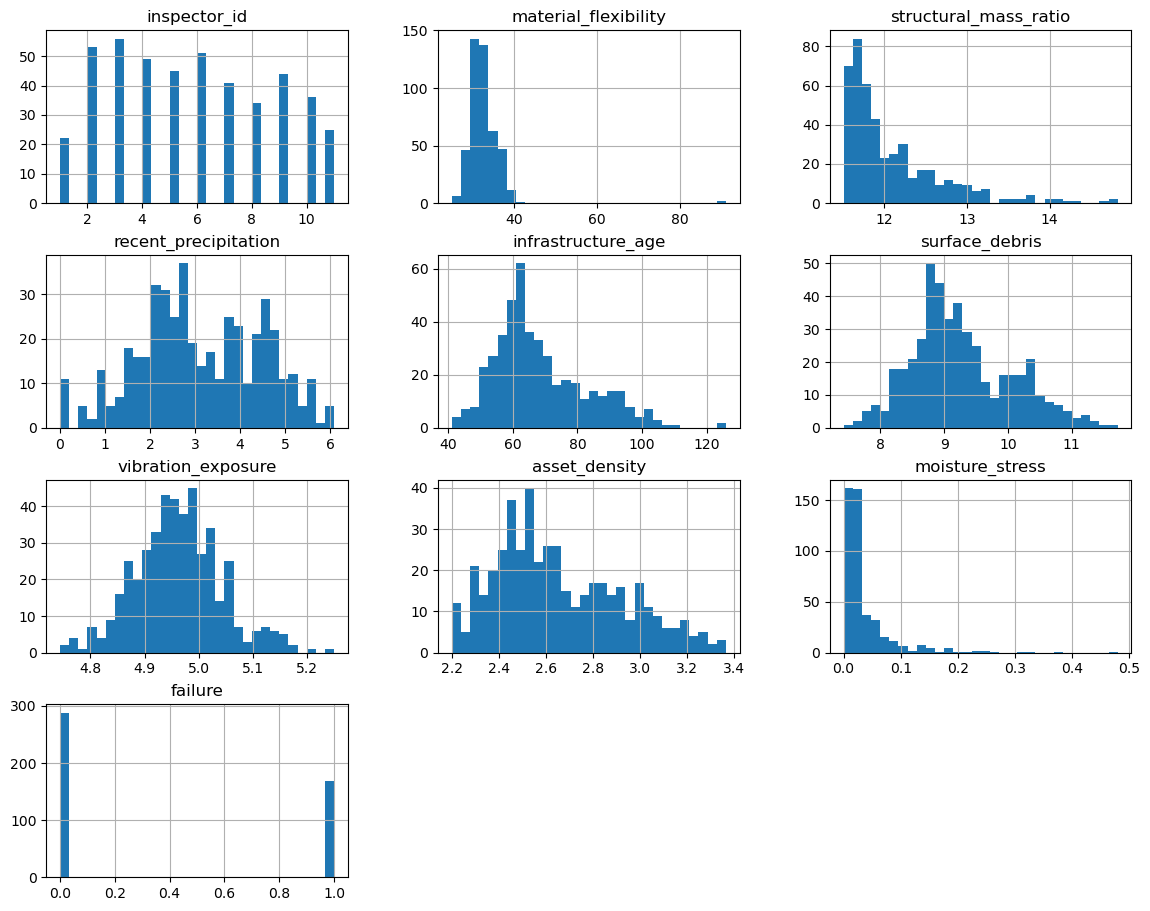

In [8]:
#Looking at distribution of data
#Hist plots of all features to check for outliers and skewness
#Hist highlights outliers in material flexibility

urbandata.hist(bins = 30, figsize = (14,11))
plt.show()

In [9]:
#Checking how many outliers there are in material flexibility, using 45 as a threshold

outliers_1 = urbandata.loc[urbandata["material_flexibility"] > 45]

display(outliers_1)

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
9,2,91.157913,12.004540,2.661193,55.022194,8.960423,4.858190,2.55912,winter,night,0.01,0
421,5,91.157913,12.053391,3.817170,64.528942,9.192685,4.953214,2.68840,winter,afternoon,0.01,0


## 2

Splitting data for training/testing


In [10]:
#define feature and target variables for splitting data into training and testing sets

X = urbandata.drop(columns = ["failure"])
y = urbandata["failure"]

In [11]:
#Splitting data into training and testing sets, using 80% of data for training and 20% for testing, setting random state to 42 for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((364, 11), (364,), (92, 11), (92,))

## 3

Clean training data

In [13]:
#1. Getting rid of unnecessary columns, such as the insector_id, which is just an identifier and does not provide any useful information for the model

X_train_cleaned = X_train.drop(columns = ["inspector_id"])
y_train_cleaned = y_train.drop(columns = ["inspector_id"])

#2. Reset index

X_train_cleaned = X_train_cleaned.reset_index(drop = True)
y_train_cleaned = y_train_cleaned.reset_index(drop = True)


In [14]:
#Getting rid of outliers in material flexibility, using 45 as a threshold

X_train_cleaned = X_train_cleaned.loc[X_train_cleaned["material_flexibility"] <= 45]
y_train_cleaned = y_train_cleaned.loc[X_train_cleaned["material_flexibility"] <= 45]

In [15]:
#Unique values function highlights a typo in the inspection season column, which is then fixed using the replace function

X_train_cleaned["inspection_season"].unique()

array(['summer', 'autumn', 'winter', 'spring', 'sumer'], dtype=object)

In [16]:
X_train_cleaned["inspection_window"].unique()   

array(['afternoon', 'morning', 'night'], dtype=object)

In [17]:
#Replacing the typo in the inspection season column, changing "sumer" to "summer"

X_train_cleaned["inspection_season"] = X_train_cleaned["inspection_season"].replace({"sumer": "summer"})
X_train_cleaned["inspection_season"].unique()

array(['summer', 'autumn', 'winter', 'spring'], dtype=object)

In [18]:
#Imputing missing values in numerical columns with the median value of each column, as the median is less affected by outliers than the mean

missing_cols = ["structural_mass_ratio", 
                "recent_precipitation",
                "infrastructure_age",
                "vibration_exposure",
                "moisture_stress"]

for col in missing_cols:
    # Calculate the median first
    median_val = X_train_cleaned[col].median()
    # Reassign the column with the filled values
    X_train_cleaned[col] = X_train_cleaned[col].fillna(median_val)


In [19]:
#Testing data now shows no null values, and all datatypes are correct

X_train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 363
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   material_flexibility   364 non-null    float64
 1   structural_mass_ratio  364 non-null    float64
 2   recent_precipitation   364 non-null    float64
 3   infrastructure_age     364 non-null    float64
 4   surface_debris         364 non-null    float64
 5   vibration_exposure     364 non-null    float64
 6   asset_density          364 non-null    float64
 7   inspection_season      364 non-null    object 
 8   inspection_window      364 non-null    object 
 9   moisture_stress        364 non-null    float64
dtypes: float64(8), object(2)
memory usage: 31.3+ KB


## 4

1. Encoding catagorical variables
2. Normalising numerical variables

In [20]:
numerical_features = X_train_cleaned.select_dtypes(include = ["int64", "float64"]).columns
categorical_features = X_train_cleaned.select_dtypes(include = ["object"]).columns

numerical_features, categorical_features

(Index(['material_flexibility', 'structural_mass_ratio', 'recent_precipitation',
        'infrastructure_age', 'surface_debris', 'vibration_exposure',
        'asset_density', 'moisture_stress'],
       dtype='object'),
 Index(['inspection_season', 'inspection_window'], dtype='object'))

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# each processing step also includes the list of columns that it will be applied to
t = [('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'), categorical_features), 
     ('num', StandardScaler(), numerical_features)]

col_transform = ColumnTransformer(transformers=t)


# fit() works out which columns to make and stores them in "enc"
col_transform.fit(X_train_cleaned)

# transform() then makes those columns in the data set we provide
X_train_encoded = col_transform.transform(X_train_cleaned)

# X_train_encoded will now be a numpy array, which can be used for training
# the columns in this are the raw data
print(X_train_encoded)

[[ 0.          1.          0.         ...  0.36817215  0.9283843
   0.75176083]
 [ 0.          0.          0.         ...  0.87683235  0.32001956
  -0.33699624]
 [ 0.          1.          0.         ...  2.25511631  1.06955985
   0.2073823 ]
 ...
 [ 1.          0.          0.         ...  1.13824438 -0.13116003
  -0.69991526]
 [ 0.          1.          0.         ... -0.63329818  0.01147093
   0.2073823 ]
 [ 1.          0.          0.         ... -1.23980044 -0.91213736
  -0.33699624]]


In [22]:
column_names = col_transform.get_feature_names_out()

# 2. Create the DataFrame using the numpy array and the new names
X_train_df = pd.DataFrame(X_train_encoded, columns=column_names)

# 3. View the first few rows
display(X_train_df.head())

,cat__inspection_season_spring,cat__inspection_season_summer,cat__inspection_season_winter,cat__inspection_window_morning,cat__inspection_window_night,num__material_flexibility,num__structural_mass_ratio,num__recent_precipitation,num__infrastructure_age,num__surface_debris,num__vibration_exposure,num__asset_density,num__moisture_stress
0,0.0,1.0,0.0,0.0,0.0,0.676087,1.561653,1.113693,0.140702,0.307539,0.368172,0.928384,0.751761
1,0.0,0.0,0.0,0.0,0.0,0.688720,-0.411249,0.235261,-0.471149,0.347004,0.876832,0.320020,-0.336996
2,0.0,1.0,0.0,1.0,0.0,1.356505,1.159524,1.179083,1.121720,1.360041,2.255116,1.069560,0.207382
3,0.0,0.0,1.0,1.0,0.0,-0.266371,-0.477386,-0.211368,-0.748477,-0.491684,-0.197999,-0.182100,-0.518456
4,0.0,0.0,0.0,0.0,1.0,-1.421876,-0.677720,-0.915748,-0.348751,-1.197761,-0.067352,-0.700228,-0.336996


## 5.

Logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize the model
# 'liblinear' is good for small datasets like urbandata.csv
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# Get the average F1-score across 5 folds
scores = cross_val_score(log_reg, X_train_encoded, y_train, cv=5, scoring='f1')
print(f"Average CV F1-Score: {scores.mean():.4f}")

Average CV F1-Score: 0.8918


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define the parameters you want to test
# C: small values = high regularization, large values = low regularization
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'] # 'l1' is Lasso, 'l2' is Ridge
}

# 2. Initialize the model (using 'liblinear' as it supports both l1 and l2)
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# 3. Set up the Grid Search
# cv=5 means 5-fold cross-validation
# scoring='f1' ensures we optimize for the balance of precision and recall
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', verbose=1)

# 4. Run the search on your training data
grid_search.fit(X_train_encoded, y_train)

# 5. View results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Validation F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 1, 'penalty': 'l2'}
Best Validation F1-Score: 0.8918


## 6.

Cleaning testing data

In [25]:
# 1. Initialize 'cleaned' versions properly
X_test_cleaned = X_test.drop(columns=["inspector_id"])
y_test_cleaned = y_test.copy() # Do NOT try to drop a column from the target Series

# 2. Create the mask based on flexibility
# At this point, X and y still share the same original indices from the split
mask = X_test_cleaned["material_flexibility"] <= 45

# 3. Apply the mask to BOTH simultaneously to keep them synchronized
X_test_cleaned = X_test_cleaned[mask]
y_test_cleaned = y_test_cleaned[mask]

# 4. NOW you can reset the index for both safely
X_test_cleaned = X_test_cleaned.reset_index(drop=True)
y_test_cleaned = y_test_cleaned.reset_index(drop=True)

print(f"Final Test set shapes: X={X_test_cleaned.shape}, y={y_test_cleaned.shape}")

Final Test set shapes: X=(90, 10), y=(90,)


In [26]:
X_test_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   material_flexibility   90 non-null     float64
 1   structural_mass_ratio  89 non-null     float64
 2   recent_precipitation   90 non-null     float64
 3   infrastructure_age     89 non-null     float64
 4   surface_debris         90 non-null     float64
 5   vibration_exposure     90 non-null     float64
 6   asset_density          90 non-null     float64
 7   inspection_season      90 non-null     object 
 8   inspection_window      90 non-null     object 
 9   moisture_stress        89 non-null     float64
dtypes: float64(8), object(2)
memory usage: 7.2+ KB


In [27]:
#Replacing the typo in the inspection season column, changing "sumer" to "summer"

X_test_cleaned["inspection_season"] = X_test_cleaned["inspection_season"].replace({"sumer": "summer"})
X_test_cleaned["inspection_season"].unique()

array(['winter', 'autumn', 'summer', 'spring'], dtype=object)

In [28]:
#Imputing missing values in numerical columns with the median value of each column, as the median is less affected by outliers than the mean

missing_cols = ["structural_mass_ratio", 
                "recent_precipitation",
                "infrastructure_age",
                "vibration_exposure",
                "moisture_stress"]

for col in missing_cols:
    # Calculate the median first
    median_val = X_train_cleaned[col].median()
    # Reassign the column with the filled values
    X_test_cleaned[col] = X_test_cleaned[col].fillna(median_val)

In [29]:
X_test_cleaned.describe()

,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,32.411056,12.099249,3.154274,68.640763,9.319551,4.972094,2.654335,0.031222
std,2.536971,0.572704,1.309399,12.728571,0.754923,0.091890,0.242360,0.033848
min,27.229581,11.506094,0.000000,49.311078,7.741735,4.774138,2.200000,0.000000
25%,30.602702,11.711190,2.198373,59.358132,8.780497,4.915299,2.455520,0.010000
50%,32.048330,11.914243,3.120616,65.534148,9.176532,4.962606,2.620200,0.020000
75%,33.987840,12.274175,4.328196,76.752453,9.858843,5.028411,2.832000,0.040000
max,39.429438,14.663824,5.993054,103.992028,11.289317,5.249006,3.302400,0.150000


Encoding testing set

In [30]:
numerical_features_test = X_test_cleaned.select_dtypes(include = ["int64", "float64"]).columns
categorical_features_test = X_test_cleaned.select_dtypes(include = ["object"]).columns

numerical_features_test, categorical_features_test

(Index(['material_flexibility', 'structural_mass_ratio', 'recent_precipitation',
        'infrastructure_age', 'surface_debris', 'vibration_exposure',
        'asset_density', 'moisture_stress'],
       dtype='object'),
 Index(['inspection_season', 'inspection_window'], dtype='object'))

In [31]:
# Use the ALREADY FITTED col_transform from your training step
# DO NOT re-define 't' or call .fit() again
X_test_encoded = col_transform.transform(X_test_cleaned)

# X_test_encoded will now be a numpy array, which can be used for training
# the columns in this are the raw data
print(X_test_encoded)

[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00 ... -8.26781252e-01
  -5.76954581e-01 -3.36996235e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 ...  2.23463123e-01
  -1.29704617e-01 -6.99915258e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  9.02275184e-01
   1.28300698e-03 -1.55536724e-01]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -2.27977102e-02
  -4.58046927e-01 -5.18455746e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 ... -1.36505279e+00
  -9.54198937e-01 -5.18455746e-01]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ...  1.09132319e+00
   4.97580559e-01  7.51760832e-01]]


c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 7.

Logistic Regression model on test set

In [32]:
# Retrieve the best estimator from grid search
best_log_reg = grid_search.best_estimator_

# Generate predictions for the test set
y_pred = best_log_reg.predict(X_test_encoded)

In [33]:
print(len(y_pred))

90


Final Test F1-Score: 0.9091
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.90      0.92      0.91        38

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90



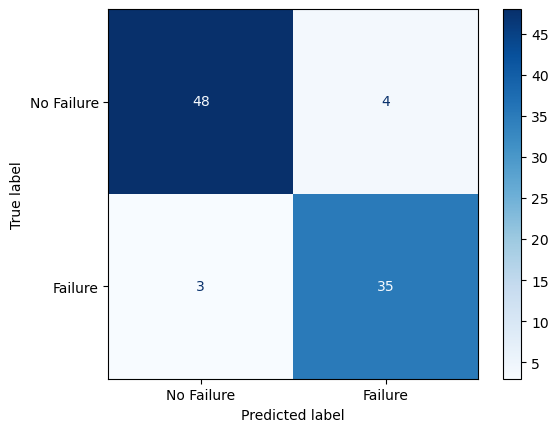

In [34]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay, classification_report

# 1. Calculate the final F1-Score on the test set
test_f1 = f1_score(y_test_cleaned, y_pred)
print(f"Final Test F1-Score: {test_f1:.4f}")

# 2. Detailed report (Precision, Recall, etc.)
print(classification_report(y_test_cleaned, y_pred))

# 3. Create and plot the Confusion Matrix
cm = confusion_matrix(y_test_cleaned, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')

## 8.

Decision Tree model

In [35]:
# X_train_tree = col_transform.transform(X_train_cleaned)
# X_test_tree = col_transform.transform(X_test_cleaned)

In [36]:
# import decision tree from sklearn
from sklearn import tree

# create and train the model
tree_clf = tree.DecisionTreeClassifier()
tree_clf = tree_clf.fit(X_train_encoded, y_train_cleaned)

In [37]:
print(len(X_train_encoded))

364


In [38]:
# import cross validation function
from sklearn.model_selection import cross_val_score

# Now, compute scores for the 5 folds (this makes 5 seperate models, and tests them
# each on a different 0.2 of the data set- returning a list of these scores).
cv_scores = cross_val_score(tree_clf, X_train_encoded, y_train_cleaned, cv=7)

# print the mean of the list of scores
print("cv_scores mean: {}".format(np.mean(cv_scores)))

cv_scores mean: 0.9038461538461539


In [39]:
# make some predictions on unseen data
y_pred_tree = tree_clf.predict(X_test_encoded)

print(len(X_test_encoded))

# # calculate accuracy of the predictions
# from sklearn import metrics
# print(metrics.accuracy_score(y_test, y_pred))

90


In [40]:
from sklearn import metrics

# Make predictions
y_pred = tree_clf.predict(X_test_encoded)

# 1. Print Accuracy with 4 decimal places
accuracy = metrics.accuracy_score(y_test_cleaned, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Print F1-Score (The primary metric for this assignment)
f1 = metrics.f1_score(y_test_cleaned, y_pred)
print(f"F1-Score: {f1:.4f}")

# 3. Generate a full report for your poster
print("\nClassification Report:")
print(metrics.classification_report(y_test_cleaned, y_pred))

Accuracy: 0.9111
F1-Score: 0.8947

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        52
           1       0.89      0.89      0.89        38

    accuracy                           0.91        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90



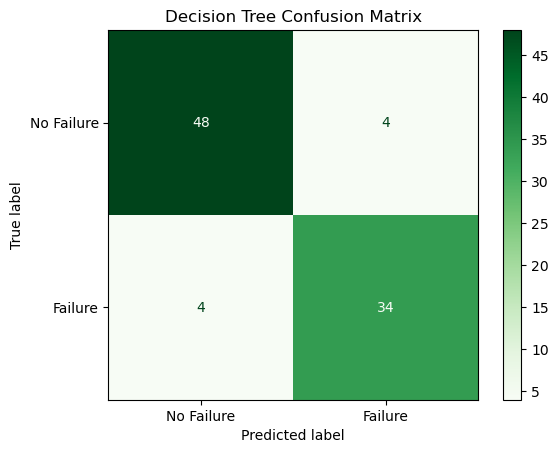

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test_cleaned, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 9.

Neural Network

In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Define a grid to find the best 'brain' structure
nn_params = {
    'hidden_layer_sizes': [(10,), (20,), (10, 10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.05] # Regularization to prevent overfitting
}

# Initialize the MLP with a fixed random_state for reproducibility
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Run GridSearchCV using F1-score
nn_grid = GridSearchCV(mlp, nn_params, cv=5, scoring='f1')
nn_grid.fit(X_train_encoded, y_train_cleaned)

print(f"Best NN Params: {nn_grid.best_params_}")
print(f"Best CV F1-Score: {nn_grid.best_score_:.4f}")

c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Danie\anaconda3\Lib\site-packages\sklearn\neural_network\_m

Best NN Params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (10,)}
Best CV F1-Score: 0.8899


In [50]:
print(f"Number of input features: {X_train_encoded.shape[1]}")

Number of input features: 13


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    # Input Layer (matching the 13 inputfeatures)
    Dense(64, activation="relu", input_shape=(X_train_encoded.shape[1],)),
    
    # Hidden Layer
    Dense(32, activation="relu"),
    
    # Output Layer: 1 neuron + sigmoid for Binary Classification (0 to 1)
    Dense(1, activation="sigmoid")
])

c:\Users\Danie\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(optimizer="adam", 
              loss="binary_crossentropy", 
              metrics=["accuracy"])

In [53]:
history = model.fit(X_train_encoded, y_train_cleaned, 
                    epochs=50, 
                    batch_size=16, 
                    validation_split=0.2) # Uses 20% of training data for validation

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7766 - loss: 0.5861 - val_accuracy: 0.8630 - val_loss: 0.4866
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9278 - loss: 0.3782 - val_accuracy: 0.8767 - val_loss: 0.3538
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9175 - loss: 0.2843 - val_accuracy: 0.8904 - val_loss: 0.3037
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9210 - loss: 0.2495 - val_accuracy: 0.8904 - val_loss: 0.2888
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9313 - loss: 0.2257 - val_accuracy: 0.8904 - val_loss: 0.2787
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9416 - loss: 0.2101 - val_accuracy: 0.8904 - val_loss: 0.2745
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9450 - loss: 0.1972 - val_accuracy: 0.8767 - val_loss: 0.2731
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9416 - loss: 0.1845 - val_accuracy: 0.8630 - v

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Final Keras F1-Score: 0.9211


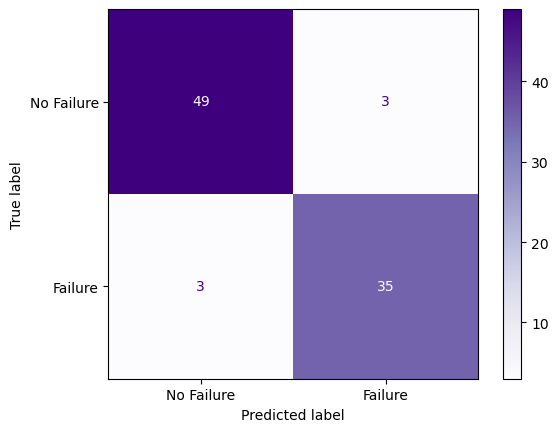

In [54]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Get raw probabilities
y_prob = model.predict(X_test_encoded)

# 2. Convert probabilities to binary (0 or 1) using 0.5 as threshold
y_pred = (y_prob > 0.5).astype("int32")

# 3. Calculate F1-Score for your Poster (Section 6)
f1 = f1_score(y_test_cleaned, y_pred)
print(f"Final Keras F1-Score: {f1:.4f}")

# 4. Generate Confusion Matrix for your Poster
cm = confusion_matrix(y_test_cleaned, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Purples')